## Resnet and H-ACN implementation

In [96]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import math
from tqdm.notebook import tqdm
from torch.utils.data import random_split
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


# Random Hierarchical Model with paper parameters

In [97]:
class RHM_Dataset(Dataset):
    def __init__(self,num_samples, L = 4, s = 2, m =4, v= 8, num_classes = 2, seed = 42):
        self.num_samples = num_samples
        self.L = L
        self.s = s
        self.m = m
        self.v = v
        self.num_classes = num_classes

        random.seed(seed)
        np.random.seed(seed)

        # construction of grammar - tree rules
        self.rules = self._generate_grammar()

        # generate data
        self.data, self.labels = self._generate_dataset()

    def _generate_grammar(self):
        rules = {}

        # for every level we create random rules
        # define intermediate for voc for intermediate levels
        intermediate_vocab = 20

        for level in range(self.L):
            rules[level] = {}
            # parents of level. for level = 0 ---> classes (0,1)
            parent_nodes = range(self.num_classes) if level == 0 else range(intermediate_vocab)

            # For every parent we make ''m '' rules
            for parent in parent_nodes:
                synonyms = []
                for _ in range(self.m):
                    if level == self.L - 1:
                        # for last level, children are from vocab v
                        child_tuple = tuple(random.choices(range(self.v), k = self.s))

                    else:
                        # in intermidiate levels, children are from  intermediate vocab
                        child_tuple = tuple(random.choices(range(intermediate_vocab), k = self.s))

                    synonyms.append(child_tuple)

                rules[level][parent] = synonyms

        print(rules)
        return rules

    def _expand_node(self,node,level):
        # Recursive function to descend the tree
        if level == self.L:
            return [node]

        # we choose randomly one of m synonyms
        chosen_rule = random.choice(self.rules[level][node])

        sequence = []

        for child in chosen_rule:
            sequence.extend(self._expand_node(child, level + 1))

        return sequence

    def _generate_dataset(self):
        data = []
        labels = []

        for _ in range(self.num_samples):
            # Randomly choose class from (0,1)
            label = random.choice(range(self.num_classes))
            sequence = self._expand_node(label, 0) # Generate sequence for the class

            data.append(sequence)
            labels.append(label)

        return torch.tensor(data, dtype=torch.long), torch.tensor(labels, dtype=torch.long)
    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        return self.data[idx], self.labels[idx]




In [98]:
test_dataset = RHM_Dataset(num_samples=5, seed=42)
print("Sequence length:", test_dataset.data.shape[1])
print("Sample 1 (Sequence):", test_dataset.data[1].tolist())
print("Sample 1 (Class):", test_dataset.labels[1].item())


{0: {0: [(12, 0), (5, 4), (14, 13), (17, 1)], 1: [(8, 0), (4, 10), (0, 3), (12, 10)]}, 1: {0: [(4, 11), (16, 0), (16, 13), (6, 3)], 1: [(19, 6), (1, 1), (16, 12), (16, 14)], 2: [(10, 19), (7, 11), (16, 12), (17, 11)], 3: [(14, 0), (4, 5), (1, 4), (2, 5)], 4: [(12, 7), (7, 4), (5, 18), (12, 12)], 5: [(3, 14), (3, 7), (19, 12), (11, 13)], 6: [(16, 15), (4, 0), (6, 5), (4, 18)], 7: [(17, 6), (13, 7), (18, 9), (5, 4)], 8: [(11, 5), (11, 17), (7, 4), (19, 10)], 9: [(1, 0), (2, 12), (15, 8), (1, 7)], 10: [(19, 10), (19, 17), (0, 14), (13, 10)], 11: [(5, 12), (2, 8), (9, 19), (17, 5)], 12: [(10, 3), (18, 17), (5, 12), (12, 3)], 13: [(15, 10), (15, 10), (0, 6), (0, 18)], 14: [(17, 16), (6, 1), (17, 18), (1, 9)], 15: [(1, 15), (15, 2), (9, 10), (5, 17)], 16: [(8, 4), (10, 14), (4, 6), (19, 12)], 17: [(8, 10), (2, 4), (6, 11), (4, 4)], 18: [(1, 12), (4, 18), (17, 1), (4, 13)], 19: [(4, 2), (18, 11), (9, 15), (16, 3)]}, 2: {0: [(1, 8), (8, 9), (14, 13), (19, 1)], 1: [(8, 6), (17, 4), (3, 8), (8, 

# Embeddings and Multihead attention implementation

In [99]:
class TokenAndPositionEmbedding(nn.Module):
    def __init__(self, vocab_size, d_model, max_seq_len = 32):
        super().__init__()

        self.token_emb = nn.Embedding(vocab_size, d_model) # Token embeddings: map integer token to a vector of size d_model
        self.pos_emb = nn.Embedding(max_seq_len, d_model) # Positional embeddings: map position index to a vector of size d_model


    def forward(self, x):
        # x shape: (batch_size, seq_len)
        seq_len = x.size(1)

        # Create position indices
        positions = torch.arange(0, seq_len, device=x.device).unsqueeze(0)

        # Add token embeddings and positional embeddings
        out = self.token_emb(x) + self.pos_emb(positions)
        return out

In [100]:
def apply_rotary_position_embeddings(tensor, cos, sin):
  # tensor shape: (batch_size, seq_len, num_heads, head_dim)
  # Split the last dimension in half for the rotary trick
  d_2 = tensor.size(-1) // 2
  x1 = tensor[..., :d_2]
  x2 = tensor[..., d_2:]

  # rotate the tensor [-x2, x1]
  rotated_tensor = torch.cat((-x2, x1), dim = -1)

  # Expand cos and sin shapes from (seq_len, head_dim) to (1, seq_len, 1, head_dim)
  # This allows proper broadcasting with the tensor
  cos = cos.unsqueeze(0).unsqueeze(2)
  sin = sin.unsqueeze(0).unsqueeze(2)

  # Apply the Rope mathematical transformation
  return (tensor * cos) + (rotated_tensor * sin)

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout =0.2, max_seq_len = 32):
        super().__init__()
        self.d_model = d_model
        self.num_heads = num_heads

        # Ensure that the model dimension is divisible by the number of heads
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.head_dim = d_model // num_heads

        # Linear Layers for Queries, Keys, and Values
        self.q_linear = nn.Linear(d_model, d_model)
        self.k_linear = nn.Linear(d_model, d_model)
        self.v_linear = nn.Linear(d_model, d_model)

        # Final output linear layer
        self.out_linear = nn.Linear(d_model, d_model)

        # Dropout Layer
        self.dropout = nn.Dropout(dropout)

        #Precompute RoPE frequencies (cos and sin)
        # Frequencies are calculated for head_dim // 2 pairs
        inv_freq = 1.0 / (10000 ** (torch.arange(0, self.head_dim, 2).float() / self.head_dim))
        positions = torch.arange(0, max_seq_len).float() # Create positions tensor from 0 to max_seq_len

        # Outer product of positions and frequencies: shape (max_seq_len, head_dim // 2)
        sinusoid_inp = torch.einsum("i,j->ij", positions, inv_freq)

        # Duplicate the frequencies to match the full head_dim
        emb = torch.cat((sinusoid_inp, sinusoid_inp), dim=-1)

        # Register as buffers so PyTorch handles device movement (CPU to GPU) automatically
        self.register_buffer("cos_cached", emb.cos())
        self.register_buffer("sin_cached", emb.sin())



    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        batch_size, seq_len, _ = x.size()

        # Linear projections for Q,K,V
        # Reshape to: (batch_size, seq_len, num_heads, head_dim)
        Q = self.q_linear(x).view(batch_size, seq_len, self.num_heads, self.head_dim)
        K = self.k_linear(x).view(batch_size, seq_len, self.num_heads, self.head_dim)
        V = self.v_linear(x).view(batch_size, seq_len, self.num_heads, self.head_dim)

        # Slice the cached cos and sin matching the current sequence length
        cos = self.cos_cached[:seq_len, :]
        sin = self.sin_cached[:seq_len, :]

        # Apply RoPE ONLY to Queries and Keys
        Q = apply_rotary_position_embeddings(Q, cos, sin)
        K = apply_rotary_position_embeddings(K, cos, sin)


        # Transpose for matrix multiplication: (batch_size, num_heads, seq_len, head_dim)
        Q = Q.transpose(1, 2)
        K = K.transpose(1, 2)
        V = V.transpose(1, 2)

        # Calculate attention scores: Q * K^T / sqrt(head_dim)
        # K.transpose(-2, -1) swaps the last two dimensions to match shapes
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)

        attn_weights = F.softmax(scores, dim=-1) # Apply softmax to get probabilities (attention weights)

        attn_weights = self.dropout(attn_weights) # Dropout

        # Multiply with Values (V) to get the weighted sum
        out = torch.matmul(attn_weights, V) # Output shape: (batch_size, num_heads, seq_len, head_dim)

        # Transpose back to: (batch_size, seq_len, num_heads, head_dim)
        # contiguous() ensures memory layout is correct before view()
        out = out.transpose(1, 2).contiguous().view(batch_size, seq_len, self.d_model)

        # Final linear projection
        return self.out_linear(out)

class FeedForward(nn.Module):
    def __init__(self, d_model, hidden_factor = 4, dropout =0.2):
        super().__init__()

        # hidden layer 4 times the d_model size
        hidden_dim = d_model * hidden_factor
        self.fc1 = nn.Linear(d_model, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, d_model)

        # dropout layer
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        x = self.fc1(x)
        x = F.gelu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        x = self.dropout(x)

        return x





In [101]:
# TEST
# dummy_x = torch.randint(0,8, (1,16)) # 1 batch, sequence of length 16 (vocab 0-7)
real_x, real_y = test_dataset[0]

real_x = real_x.unsqueeze(0) # real_x has shape [16]. We need to add the batch dimension to make it [1, 16]
print(f"Original Sequence: {real_x.tolist()}")
print(f"Target Class: {real_y.item()}\n")


d_model = 128
num_heads = 4

emb_layer = TokenAndPositionEmbedding(vocab_size=8, d_model=d_model)
mha_layer = MultiHeadAttention(d_model=d_model, num_heads=num_heads)
ffn_layer = FeedForward(d_model=d_model)

embedded_x = emb_layer(real_x)
attn_out = mha_layer(embedded_x)
ffn_out = ffn_layer(attn_out)

print("Input shape:", real_x.shape)
print("After Embedding shape:", embedded_x.shape)
print("After Attention shape:", attn_out.shape)
print("After FFN shape:", ffn_out.shape)

Original Sequence: [[7, 0, 0, 3, 5, 7, 3, 5, 3, 7, 3, 1, 0, 4, 1, 6]]
Target Class: 1

Input shape: torch.Size([1, 16])
After Embedding shape: torch.Size([1, 16, 128])
After Attention shape: torch.Size([1, 16, 128])
After FFN shape: torch.Size([1, 16, 128])


#Depth-Adaptive Layer Norm

In [102]:
class DepthLN(nn.Module):
  def __init__(self, d_model, depth):
    super().__init__()
    self.depth = depth
    self.ln = nn.LayerNorm(d_model)
    self.s = nn.Parameter(torch.tensor(0.05)) # Learnable strength factor s initialized at 0.05 per layer

  def forward(self, x):
    # a = 1 + l*s
    alpha_l = 1 + (self.depth * self.s)
    return self.ln(x) * alpha_l


# Transformer Block

In [103]:
class CustomTransformerBlock(nn.Module):
    def __init__(self, d_model, num_heads,depth, mode ="h-acn"):
        super().__init__()
        self.mode = mode


        # bring the blocks from previous steps
        self.mha = MultiHeadAttention(d_model=d_model, num_heads=num_heads)
        self.ffn = FeedForward(d_model=d_model)

        # Layer Normalization
        self.ln1 = DepthLN(d_model,depth)
        self.ln2 = DepthLN(d_model,depth)

        # Initialize the alpha parameter based on mode
        if self.mode == "resnet":
            self.alpha = nn.Parameter(torch.tensor(1.0), requires_grad= False)
        elif self.mode == "acn":
            self.alpha = nn.Parameter(torch.tensor(0.0), requires_grad=False)
        elif self.mode == "h-acn":
            self.alpha = nn.Parameter(torch.tensor(1.0), requires_grad=True)

    def forward(self, x):
        # Calculate the new information from attention
        normalized_x = self.ln1(x)
        attention_output = self.mha(normalized_x)

        # # CONSTRAINED ALPHA
        # # Constrain alpha between 0.0 and 1.2
        # clamped_alpha = torch.clamp(self.alpha, min=0.0, max=1.2)

        # UNCONSTRAINED alpha
        # Calculate the new information from FFN
        h_local = x + attention_output
        normalized_h = self.ln2(h_local)
        ffn_output = self.ffn(normalized_h)

        # Calculate the total new information produced by this layer: F(x)
        # This is what goes to the global accumulator (y)
        f_x = attention_output + ffn_output

        # Calculate what goes to the NEXT layer
        # x_next = alpha * x + F(x)
        x_next = (self.alpha * x) + f_x




        # x_next goes to the next block, f_x goes to global 'y' sum
        return x_next, f_x

In [104]:
# TEST
real_x, real_y = test_dataset[0]
real_x = real_x.unsqueeze(0) # Shape becomes [1, 16]

print(f"Original Sequence (Input): {real_x.tolist()}")

d_model = 128
num_heads = 4

# Initialize the embedding Layer and one Custom Transformer Block
emb_layer = TokenAndPositionEmbedding(vocab_size=8, d_model=d_model)
hacn_block = CustomTransformerBlock(d_model=d_model, num_heads=num_heads,depth = 1, mode="h-acn")

# Pass the data through sequence and pass the vectors into our custom block
embedded_x = emb_layer(real_x)
print(f"Shape after Embedding: {embedded_x.shape}")

next_layer_input, global_contribution = hacn_block(embedded_x)
print(f"Shape for next layer (Local Flow - x_next): {next_layer_input.shape}")
print(f"Shape for global sum (Global Flow - f_x): {global_contribution.shape}")

Original Sequence (Input): [[7, 0, 0, 3, 5, 7, 3, 5, 3, 7, 3, 1, 0, 4, 1, 6]]
Shape after Embedding: torch.Size([1, 16, 128])
Shape for next layer (Local Flow - x_next): torch.Size([1, 16, 128])
Shape for global sum (Global Flow - f_x): torch.Size([1, 16, 128])


# H-ACN Model

In [105]:
class HACN_Model(nn.Module):
    def __init__(self, vocab_size = 8, num_classes = 2, d_model = 128, num_heads = 4, num_layers = 8, mode = 'h-acn'):
        super().__init__()
        self.mode = mode
        self.num_layers = num_layers

        # Embedding Layer
        self.embedding = TokenAndPositionEmbedding(vocab_size, d_model)

        # We use nn.ModuleList to hold our 8 sequential blocks
        self.layers = nn.ModuleList([
            CustomTransformerBlock(d_model, num_heads,depth=i+1, mode=mode) for i in range(num_layers)
        ])

        self.final_ln = nn.LayerNorm(d_model)
        self.classifier = nn.Linear(16 * d_model, num_classes)

    def forward(self, x):
        # x shape: (batch_size, seq_len)

        # Embedding Layer
        x_emb = self.embedding(x) # shape: (batch_size, seq_len, d_model)

        # Initialize the dual pathways
        global_y = x_emb # y starts as a x_0
        local_x = x_emb # local flow

        for layer in self.layers:
            local_x, f_x = layer(local_x) # The layer returns the input for the next layer and the new information f(x) for the global sum

            global_y = global_y + f_x # Add the new information directly to the global accumulator

        # global_y shape (batch_size, seq_len, d_model) -> (batch_size, d_model)
        # pooled_output = global_y.mean(dim=1)

        # Idea 1
        # Extract the representation of the LAST token in the sequence.
        # global_y shape: (batch_size, seq_len, d_model) -> (batch_size, d_model)
        # pooled_output = global_y[:, -1, :]

        # Idea 2
        # # Final normalization
        # pooled_output = self.final_ln(pooled_output)

        # Idea 3
        # Flattening: from (batch_size, 16, 128) -> (batch_size,2048)
        batch_size = global_y.size(0)
        pooled_output = global_y.view(batch_size, -1)

        # Final logits
        logits = self.classifier(pooled_output)

        return logits

    def get_alphas(self):
        # extract alpha values

        alphas = []
        for layer in self.layers:
            alphas.append(layer.alpha.item())

        return alphas


In [106]:
# TEST
real_x, real_y = test_dataset[0]
real_x = real_x.unsqueeze(0)

# Initialize the complete model in H-ACN mode with 8 layers
model = HACN_Model(num_layers=8, mode="h-acn")

logits = model(real_x)

print(f"Input Sequence Shape: {real_x.shape}")
print(f"Output Logits Shape: {logits.shape}")
print(f"Output Logits Values: {logits.detach().numpy()}")
print(f"Target Class: {real_y.item()}")
print(f"\nInitial Alpha values across the 8 layers:")
print(model.get_alphas())


Input Sequence Shape: torch.Size([1, 16])
Output Logits Shape: torch.Size([1, 2])
Output Logits Values: [[-0.42019466 -1.5879105 ]]
Target Class: 1

Initial Alpha values across the 8 layers:
[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


# Train - Test dataset

In [107]:
full_dataset = RHM_Dataset(num_samples=20000, seed = 15)

train_size = 10000
test_size = 10000

train_dataset, test_dataset = random_split(full_dataset, [train_size, test_size])

print(f"\nTrain dataset size: {len(train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

{0: {0: [(19, 0), (14, 3), (19, 0), (17, 13)], 1: [(17, 19), (4, 6), (14, 5), (5, 4)]}, 1: {0: [(17, 17), (15, 4), (18, 10), (4, 9)], 1: [(8, 1), (11, 7), (11, 18), (12, 8)], 2: [(17, 19), (9, 18), (0, 2), (3, 18)], 3: [(13, 14), (5, 9), (17, 1), (2, 0)], 4: [(9, 16), (11, 8), (10, 3), (18, 7)], 5: [(4, 6), (16, 6), (18, 6), (8, 1)], 6: [(18, 15), (9, 2), (9, 7), (16, 18)], 7: [(14, 5), (0, 17), (18, 3), (9, 9)], 8: [(19, 0), (1, 16), (11, 9), (15, 11)], 9: [(13, 5), (1, 0), (6, 12), (7, 6)], 10: [(12, 14), (11, 6), (16, 16), (17, 17)], 11: [(0, 13), (6, 7), (10, 2), (4, 19)], 12: [(6, 18), (13, 6), (6, 12), (14, 6)], 13: [(1, 3), (17, 14), (2, 16), (11, 6)], 14: [(17, 2), (1, 6), (14, 10), (9, 18)], 15: [(7, 15), (0, 15), (3, 13), (16, 13)], 16: [(11, 11), (15, 7), (4, 11), (10, 2)], 17: [(10, 9), (3, 14), (15, 6), (17, 19)], 18: [(13, 8), (5, 2), (5, 19), (1, 18)], 19: [(13, 15), (1, 12), (4, 13), (15, 14)]}, 2: {0: [(10, 17), (4, 3), (17, 1), (8, 8)], 1: [(17, 7), (11, 10), (9, 9), 

# Training and Evaluation Loop

In [108]:
# HyperParameter setup
batch_size = 64
learning_rate = 1e-3
epochs = 128
mode = 'resnet'


# Dataloaders
train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle= True)
test_loader = DataLoader(test_dataset, batch_size= batch_size, shuffle= False)

# Initialize the model, loss function and optimizer
model = HACN_Model(num_layers=8, mode = mode).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr = learning_rate, weight_decay=0.01)



# Initialize the Cosine Annealing Learning Rate Scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max = epochs)

loss_history = []
accuracy_history = []
alpha_history = []

for epoch in range(epochs):
    model.train()
    total_loss = 0.0

    progress_bar = tqdm(train_loader, desc = f"Epoch {epoch+1}/{epochs}")

    for batch_x, batch_y in progress_bar:
        # Move to gpu
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)

        # Forward pass
        logits = model(batch_x)
        loss = criterion(logits, batch_y)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()

        # Update weights and alphas
        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix({'loss': loss.item()})

    # Scheduler adjust
    scheduler.step()

    # Average loss for epoch
    avg_loss = total_loss / len(train_loader)
    loss_history.append(avg_loss)

    current_alphas = model.get_alphas()
    alpha_history.append(current_alphas)

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for batch_x, batch_y in test_loader:

            # Move to gpu
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)

            logits = model(batch_x)

            # The predicted class is the index with the highest logit score
            predictions = torch.argmax(logits, dim=1)

            correct += (predictions == batch_y).sum().item()
            total += batch_y.size(0)

    # Accuracy
    epoch_acc = correct / total
    accuracy_history.append(epoch_acc)

    current_lr = scheduler.get_last_lr()[0]
    print(f"Epoch {epoch+1} Summary | Loss: {avg_loss:.4f} | Test Acc: {epoch_acc:.4f} | LR: {current_lr:.6f}")




Epoch 1/128:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 1 Summary | Loss: 0.7749 | Test Acc: 0.6879 | LR: 0.001000


Epoch 2/128:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 2 Summary | Loss: 0.5522 | Test Acc: 0.7580 | LR: 0.000999


Epoch 3/128:   0%|          | 0/157 [00:00<?, ?it/s]

...

Epoch 126 Summary | Loss: 0.0015 | Test Acc: 0.8854 | LR: 0.000001


Epoch 127/128:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 127 Summary | Loss: 0.0016 | Test Acc: 0.8853 | LR: 0.000000


Epoch 128/128:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 128 Summary | Loss: 0.0016 | Test Acc: 0.8853 | LR: 0.000000


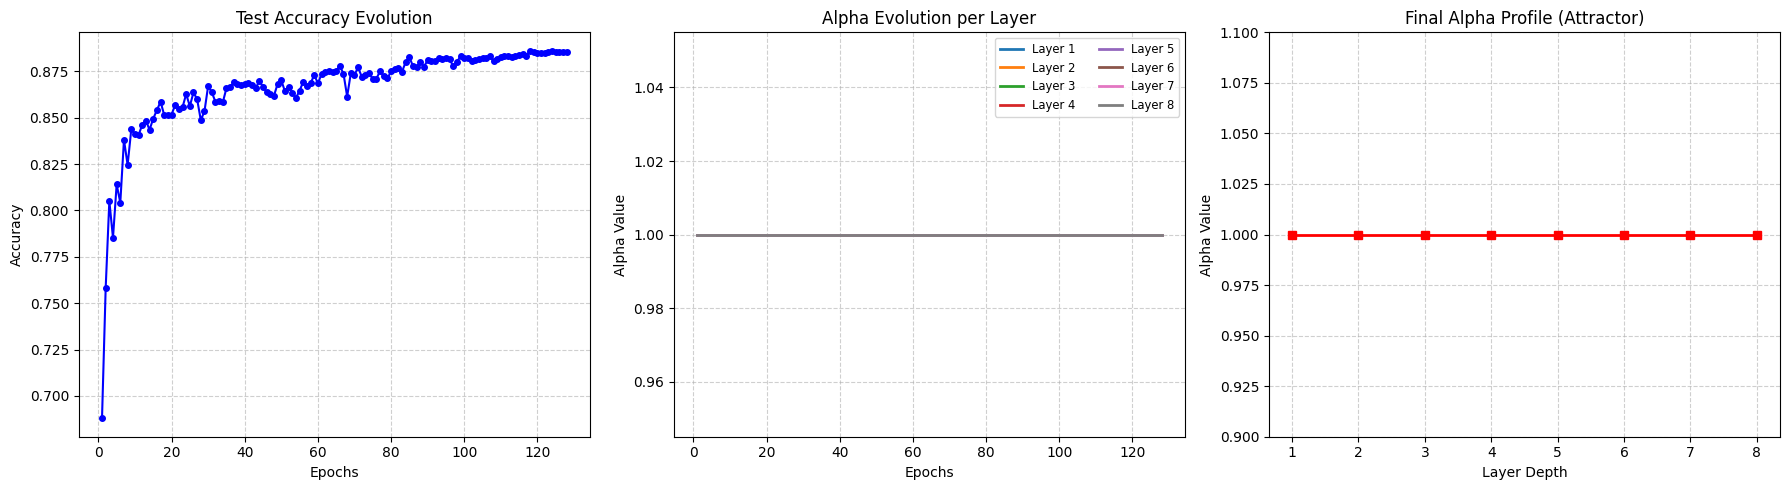

Final Test Accuracy: 0.8853
Final Alpha values per layer:
  Layer 1: 1.0000
  Layer 2: 1.0000
  Layer 3: 1.0000
  Layer 4: 1.0000
  Layer 5: 1.0000
  Layer 6: 1.0000
  Layer 7: 1.0000
  Layer 8: 1.0000


In [109]:
# Plotting results
# Convert lists to numpy array

acc_array = np.array(accuracy_history)
alpha_array = np.array(alpha_history)

#PLOTS
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy
axes[0].plot(range(1, len(acc_array) + 1), acc_array, marker='o', color='b', markersize=4)
axes[0].set_title('Test Accuracy Evolution')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].grid(True, linestyle='--', alpha=0.6)

# Alpha
for layer_idx in range(alpha_array.shape[1]):
    axes[1].plot(range(1, len(alpha_array) + 1), alpha_array[:, layer_idx],
                 label=f'Layer {layer_idx + 1}', linewidth=2)

axes[1].set_title('Alpha Evolution per Layer')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Alpha Value')
axes[1].legend(loc='upper right', fontsize='small', ncol=2)
axes[1].grid(True, linestyle='--', alpha=0.6)


# Alpha profile
final_alphas = alpha_array[-1, :]
axes[2].plot(range(1, len(final_alphas) + 1), final_alphas, marker='s', color='r', linewidth=2)
axes[2].set_title('Final Alpha Profile (Attractor)')
axes[2].set_xlabel('Layer Depth')
axes[2].set_ylabel('Alpha Value')
axes[2].set_xticks(range(1, len(final_alphas) + 1))
axes[2].set_ylim(min(final_alphas) - 0.1, max(final_alphas) + 0.1)
axes[2].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print(f"Final Test Accuracy: {acc_array[-1]:.4f}")
print("Final Alpha values per layer:")
for i, alpha_val in enumerate(final_alphas):
    print(f"  Layer {i+1}: {alpha_val:.4f}")